# SEN-HARP Core v0.4 — analyse des sept expériences

Ce notebook n'importe ni `Model` ni `Parameters`. Il ne contient aucune règle économique. Il lit uniquement les CSV exportés, construit des agrégations et produit des graphiques.

Exécuter d'abord `01_run_seven_experiments.ipynb`.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "experiments" / "seven_experiments.json").is_file()
            and (candidate / "outputs" / "seven_experiments").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Résultats introuvables. Exécutez d'abord le notebook de lancement."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "experiments" / "seven_experiments.json"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "seven_experiments"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

with CONFIG_PATH.open("r", encoding="utf-8") as stream:
    CONFIG = json.load(stream)

EXPERIMENT_ORDER = [item["id"] for item in CONFIG["experiments"]]
LABELS = {item["id"]: item["label"] for item in CONFIG["experiments"]}
FIXED_EXPERIMENTS = ["E0_baseline", "E1_carbon_tax_fixed", "E3_green_deal_fixed", "E5_post_growth_fixed"]
FAMILY_COLORS = {"E0": "#4d4d4d", "E1": "#2878b5", "E2": "#2878b5", "E3": "#e68613", "E4": "#e68613", "E5": "#3a923a", "E6": "#3a923a"}

PROJECT_ROOT


WindowsPath('C:/Users/saintjea/MesNotebooks/SEN_HARP/senharp_core_v0.4')

In [3]:
def load_table(table_name: str) -> pd.DataFrame:
    frames = []
    for experiment in CONFIG["experiments"]:
        path = OUTPUT_ROOT / experiment["id"] / f"{table_name}.csv"
        if not path.is_file():
            raise FileNotFoundError(path)
        frames.append(pd.read_csv(path))
    return pd.concat(frames, ignore_index=True)

macro = load_table("macro")
firms = load_table("firms")
households = load_table("households")
government = load_table("government")

for name, table in {
    "macro": macro,
    "firms": firms,
    "households": households,
    "government": government,
}.items():
    print(name, table.shape)


macro (182, 40)
firms (21840, 72)
households (109200, 49)
government (182, 33)


## Fonctions purement descriptives

Les fonctions suivantes sélectionnent des colonnes existantes, agrègent par expérience et période, puis tracent les séries.


In [4]:
def first_existing_column(table: pd.DataFrame, candidates: list[str]) -> str | None:
    return next((column for column in candidates if column in table.columns), None)


def aggregate_mean(
    table: pd.DataFrame,
    value_column: str,
    output_name: str,
) -> pd.DataFrame:
    return (
        table.groupby(
            ["experiment_id", "experiment_label", "period"],
            as_index=False,
        )[value_column]
        .mean()
        .rename(columns={value_column: output_name})
    )


def aggregate_sum(
    table: pd.DataFrame,
    value_column: str,
    output_name: str,
) -> pd.DataFrame:
    return (
        table.groupby(
            ["experiment_id", "experiment_label", "period"],
            as_index=False,
        )[value_column]
        .sum()
        .rename(columns={value_column: output_name})
    )


def plot_trajectories(
    table: pd.DataFrame,
    value_column: str,
    title: str,
    y_label: str,
    filename: str,
    experiments: list[str] | None = None,
) -> None:
    plot_data = table.copy()
    if experiments is not None:
        plot_data = plot_data[
            plot_data["experiment_id"].isin(experiments)
        ]

    fig, ax = plt.subplots(figsize=(11, 6))
    for experiment_id in EXPERIMENT_ORDER:
        subset = plot_data[
            plot_data["experiment_id"] == experiment_id
        ].sort_values("period")
        if subset.empty:
            continue
        ax.plot(
            subset["period"],
            subset[value_column],
            marker="o",
            linewidth=1.8,
            markersize=3,
            label=LABELS[experiment_id],
            color=FAMILY_COLORS[experiment_id[:2]],
            linestyle="--" if "vote" in experiment_id else "-",
        )

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel(y_label)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / filename, dpi=200, bbox_inches="tight")
    plt.show()


## Agrégations principales

Ces tables sont construites uniquement à partir des sorties du collector.


In [5]:
needs_col = first_existing_column(
    households, ["needs_index", "NeedsIndex"]
)
income_col = first_existing_column(
    households,
    ["economic_disposable_income", "mean_economic_disposable_income"],
)
vote_probability_col = first_existing_column(
    households, ["vote_probability", "VoteProb"]
)
vote_col = first_existing_column(
    households, ["vote", "VoteDecision"]
)

actual_output_col = first_existing_column(
    firms, ["actual_output", "output", "production"]
)
potential_output_col = first_existing_column(
    firms, ["potential_output", "productive_capacity"]
)
profits_col = first_existing_column(
    firms, ["profits", "profit"]
)
brown_capital_col = first_existing_column(
    firms, ["brown_capital"]
)
green_capital_col = first_existing_column(
    firms, ["green_capital", "productive_green_capital"]
)

public_debt_col = first_existing_column(
    government, ["public_debt"]
)
primary_deficit_col = first_existing_column(
    government, ["primary_deficit"]
)

print({
    "needs": needs_col,
    "income": income_col,
    "vote_probability": vote_probability_col,
    "vote": vote_col,
    "actual_output": actual_output_col,
    "potential_output": potential_output_col,
    "profits": profits_col,
    "brown_capital": brown_capital_col,
    "green_capital": green_capital_col,
    "public_debt": public_debt_col,
    "primary_deficit": primary_deficit_col,
})


{'needs': 'needs_index', 'income': 'economic_disposable_income', 'vote_probability': 'vote_probability', 'vote': 'vote', 'actual_output': 'actual_output', 'potential_output': 'potential_output', 'profits': 'profits', 'brown_capital': 'brown_capital', 'green_capital': 'green_capital', 'public_debt': 'public_debt', 'primary_deficit': 'primary_deficit'}


In [6]:
period_tables = {}

if "real_gdp" in macro.columns:
    period_tables["real_gdp"] = aggregate_mean(
        macro, "real_gdp", "real_gdp"
    )

if "nominal_gdp" in macro.columns:
    period_tables["nominal_gdp"] = aggregate_mean(
        macro, "nominal_gdp", "nominal_gdp"
    )

if needs_col:
    period_tables["mean_needs_index"] = aggregate_mean(
        households, needs_col, "mean_needs_index"
    )

if income_col:
    period_tables["mean_disposable_income"] = aggregate_mean(
        households, income_col, "mean_disposable_income"
    )

if vote_probability_col:
    period_tables["mean_vote_probability"] = aggregate_mean(
        households, vote_probability_col, "mean_vote_probability"
    )

if vote_col:
    period_tables["realised_support"] = aggregate_mean(
        households, vote_col, "realised_support"
    )

if actual_output_col:
    period_tables["total_actual_output"] = aggregate_sum(
        firms, actual_output_col, "total_actual_output"
    )

if potential_output_col:
    period_tables["total_potential_output"] = aggregate_sum(
        firms, potential_output_col, "total_potential_output"
    )

if profits_col:
    period_tables["total_profits"] = aggregate_sum(
        firms, profits_col, "total_profits"
    )

if brown_capital_col:
    period_tables["total_brown_capital"] = aggregate_sum(
        firms, brown_capital_col, "total_brown_capital"
    )

if green_capital_col:
    period_tables["total_green_capital"] = aggregate_sum(
        firms, green_capital_col, "total_green_capital"
    )

if public_debt_col:
    period_tables["public_debt"] = aggregate_mean(
        government, public_debt_col, "public_debt"
    )

if primary_deficit_col:
    period_tables["primary_deficit"] = aggregate_mean(
        government, primary_deficit_col, "primary_deficit"
    )

list(period_tables)


['mean_needs_index',
 'mean_disposable_income',
 'mean_vote_probability',
 'realised_support',
 'total_actual_output',
 'total_potential_output',
 'total_profits',
 'total_brown_capital',
 'total_green_capital',
 'public_debt',
 'primary_deficit']

## Graphiques comparatifs

Chaque figure est également enregistrée dans `outputs/seven_experiments/figures/`.


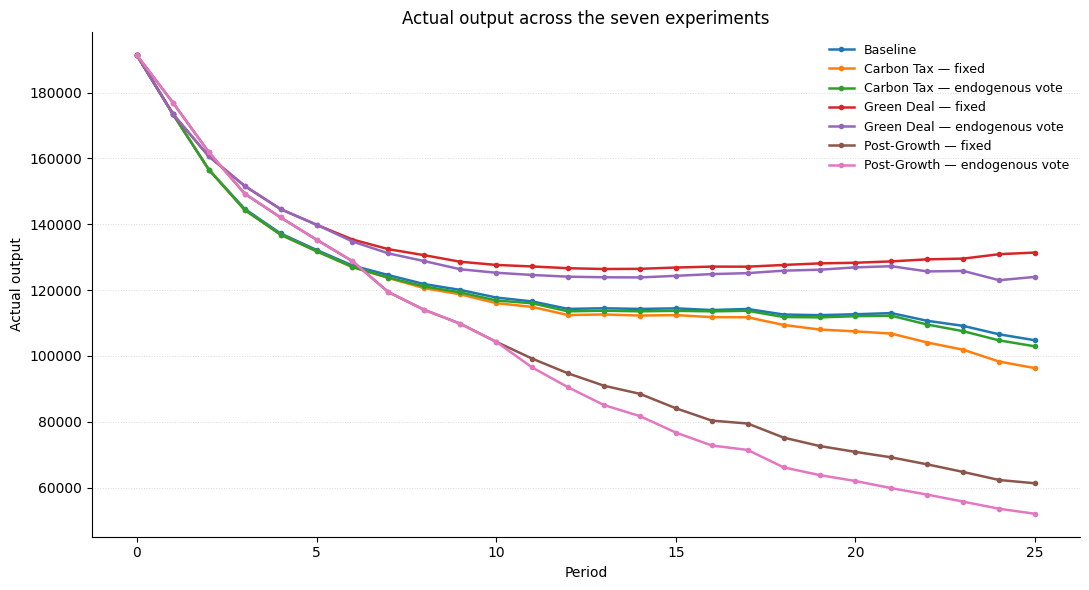

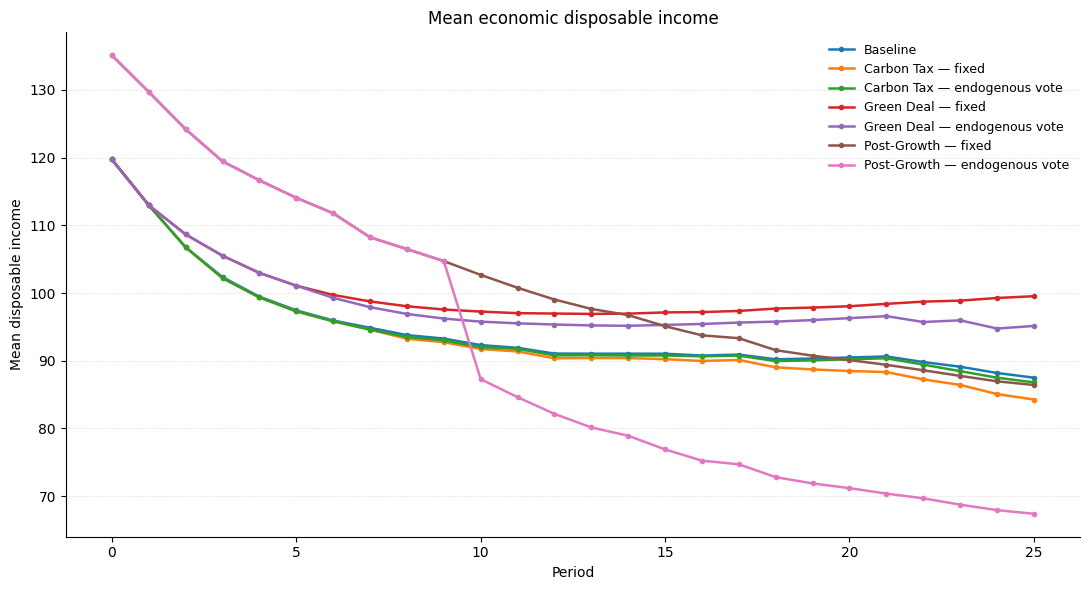

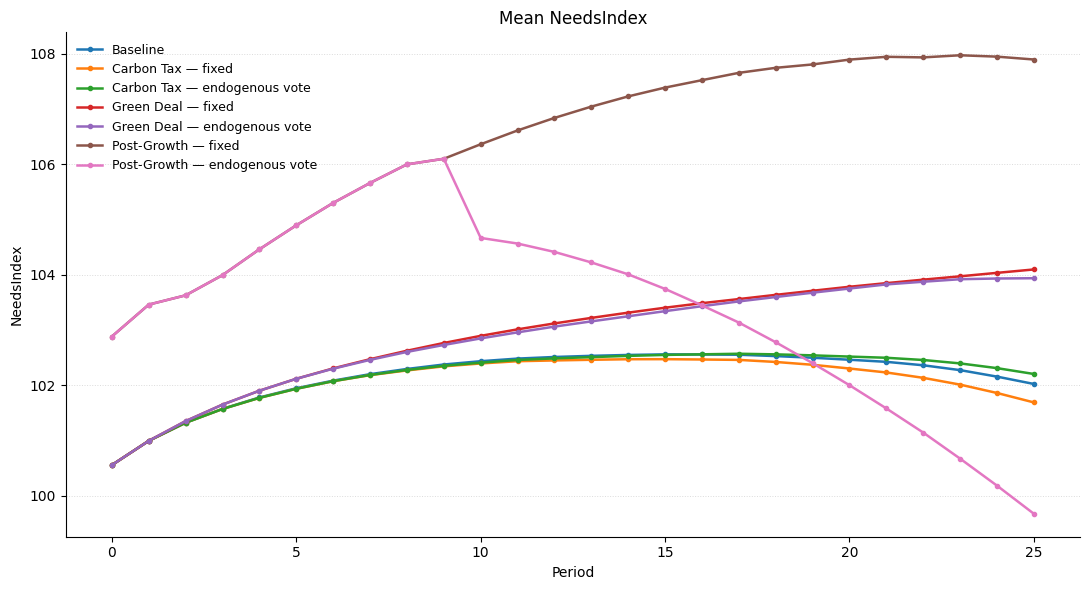

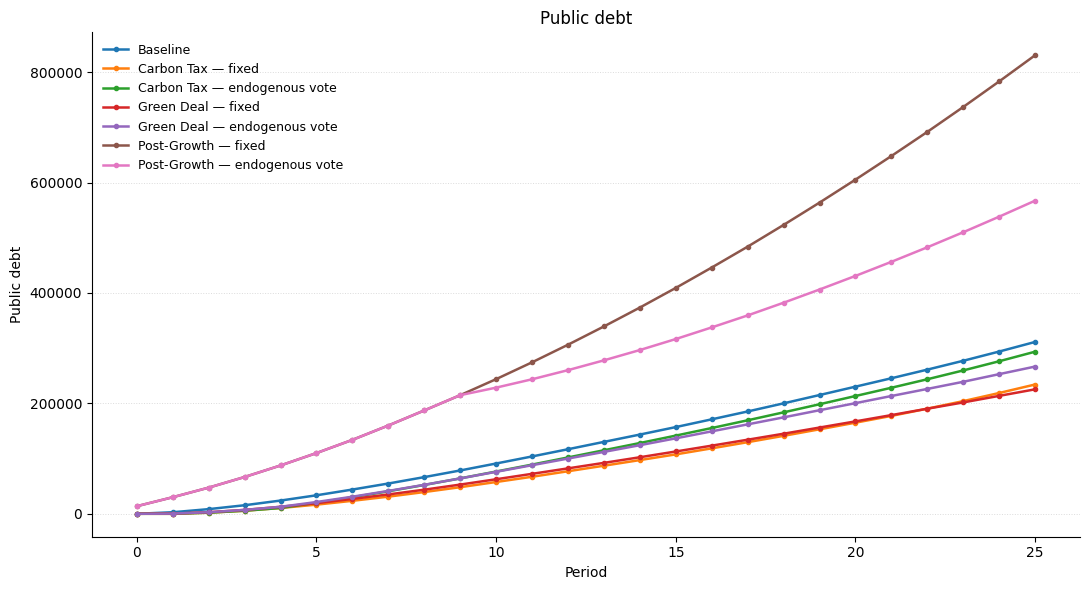

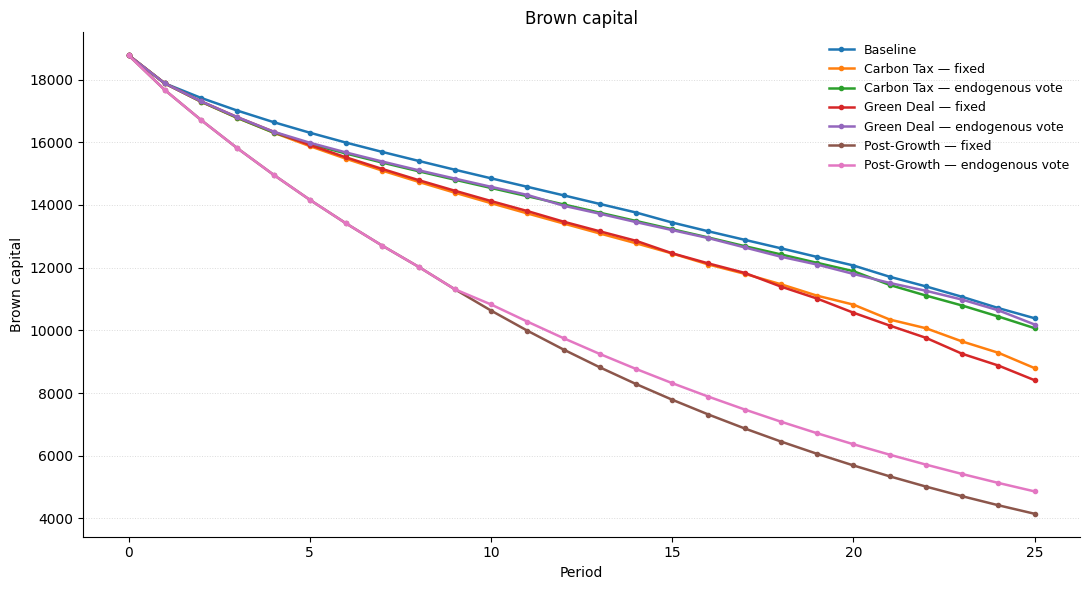

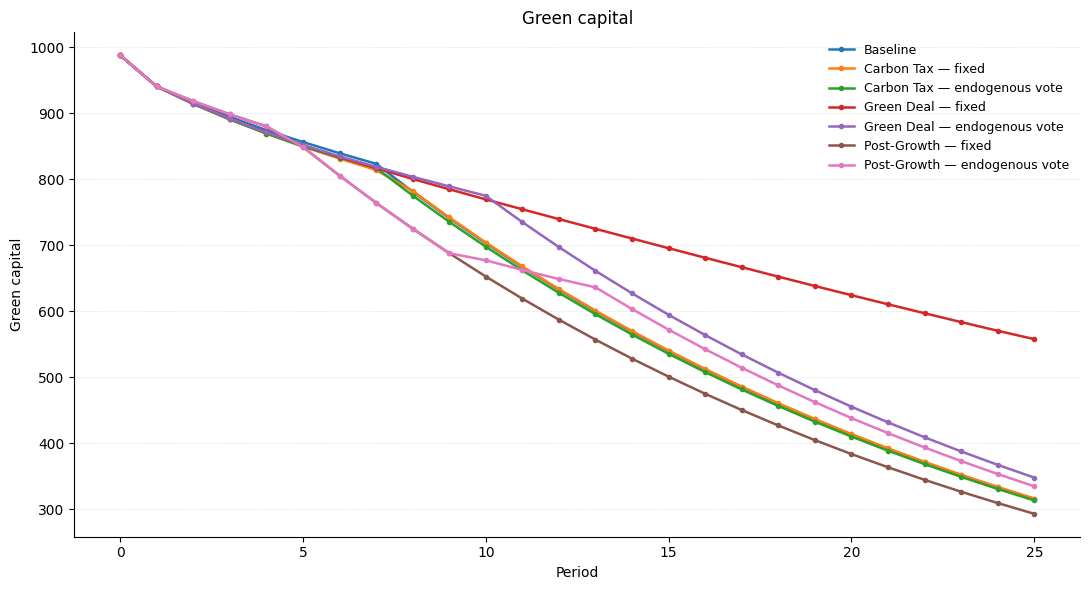

In [7]:
if "real_gdp" in period_tables:
    plot_trajectories(
        period_tables["real_gdp"],
        "real_gdp",
        "Real GDP across the seven experiments",
        "Real GDP (period-0 prices)",
        "00_real_gdp.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "total_actual_output" in period_tables:
    plot_trajectories(
        period_tables["total_actual_output"],
        "total_actual_output",
        "Actual output across the seven experiments",
        "Actual output",
        "01_actual_output.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "mean_disposable_income" in period_tables:
    plot_trajectories(
        period_tables["mean_disposable_income"],
        "mean_disposable_income",
        "Mean economic disposable income",
        "Mean disposable income",
        "02_disposable_income.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "mean_needs_index" in period_tables:
    plot_trajectories(
        period_tables["mean_needs_index"],
        "mean_needs_index",
        "Mean NeedsIndex",
        "NeedsIndex",
        "03_needs_index.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "public_debt" in period_tables:
    plot_trajectories(
        period_tables["public_debt"],
        "public_debt",
        "Public debt",
        "Public debt",
        "04_public_debt.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "total_brown_capital" in period_tables:
    plot_trajectories(
        period_tables["total_brown_capital"],
        "total_brown_capital",
        "Brown capital",
        "Brown capital",
        "05_brown_capital.png",
        experiments=FIXED_EXPERIMENTS,
    )

if "total_green_capital" in period_tables:
    plot_trajectories(
        period_tables["total_green_capital"],
        "total_green_capital",
        "Green capital",
        "Green capital",
        "06_green_capital.png",
        experiments=FIXED_EXPERIMENTS,
    )


## Indicateurs environnementaux

Le notebook cherche les noms de colonnes présents dans les sorties macro. Aucune transformation causale n'est appliquée.


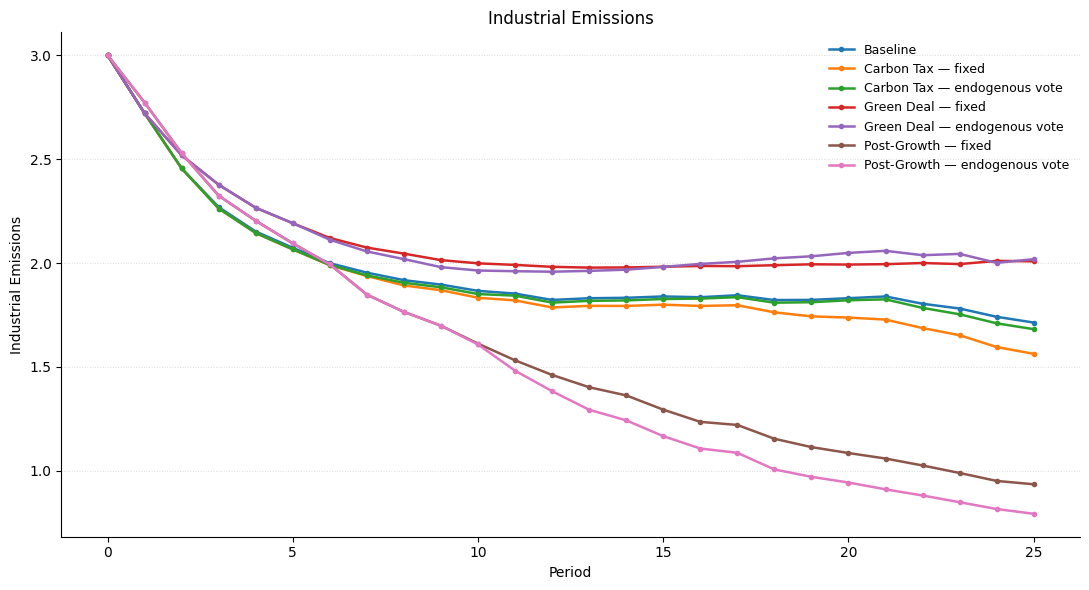

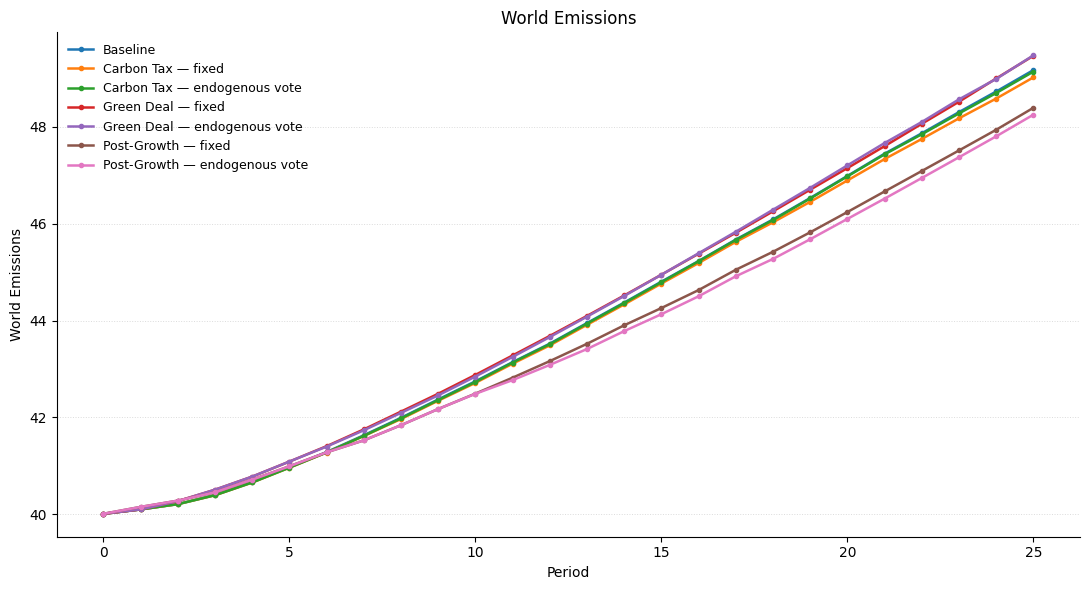

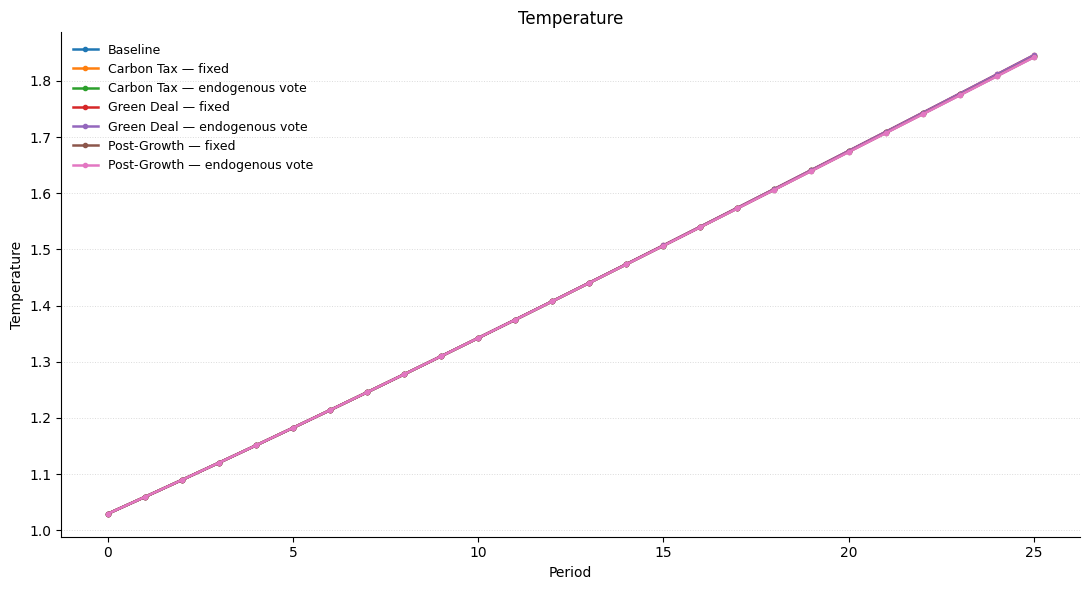

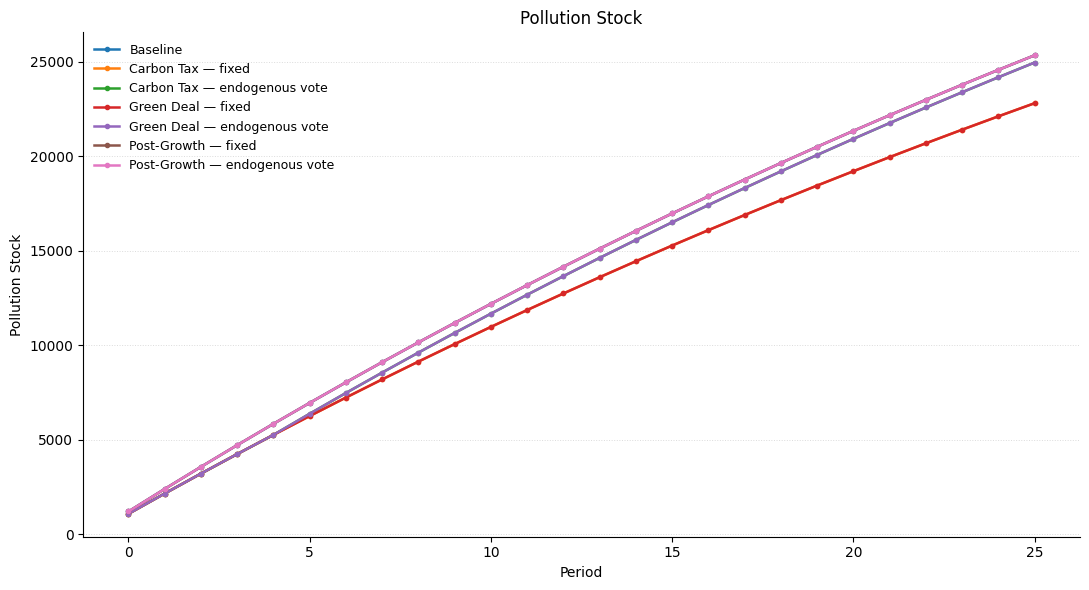

In [8]:
environment_candidates = {
    "industrial_emissions": [
        "industrial_emissions",
        "total_industrial_emissions",
    ],
    "world_emissions": [
        "world_emissions",
        "total_world_emissions",
    ],
    "temperature": [
        "temperature",
        "atmospheric_temperature",
    ],
    "pollution_stock": [
        "pollution_stock",
        "atmospheric_pollution_stock",
    ],
}

for output_name, candidates in environment_candidates.items():
    column = first_existing_column(macro, candidates)
    if column is None:
        print(f"Skipped {output_name}: no matching column.")
        continue

    table = aggregate_mean(macro, column, output_name)
    period_tables[output_name] = table

    plot_trajectories(
        table,
        output_name,
        output_name.replace("_", " ").title(),
        output_name.replace("_", " ").title(),
        f"environment_{output_name}.png",
        experiments=FIXED_EXPERIMENTS,
    )


## Politique : expériences avec vote

Les graphiques politiques sont limités à E2, E4 et E6. Les périodes électorales proviennent du fichier de configuration.


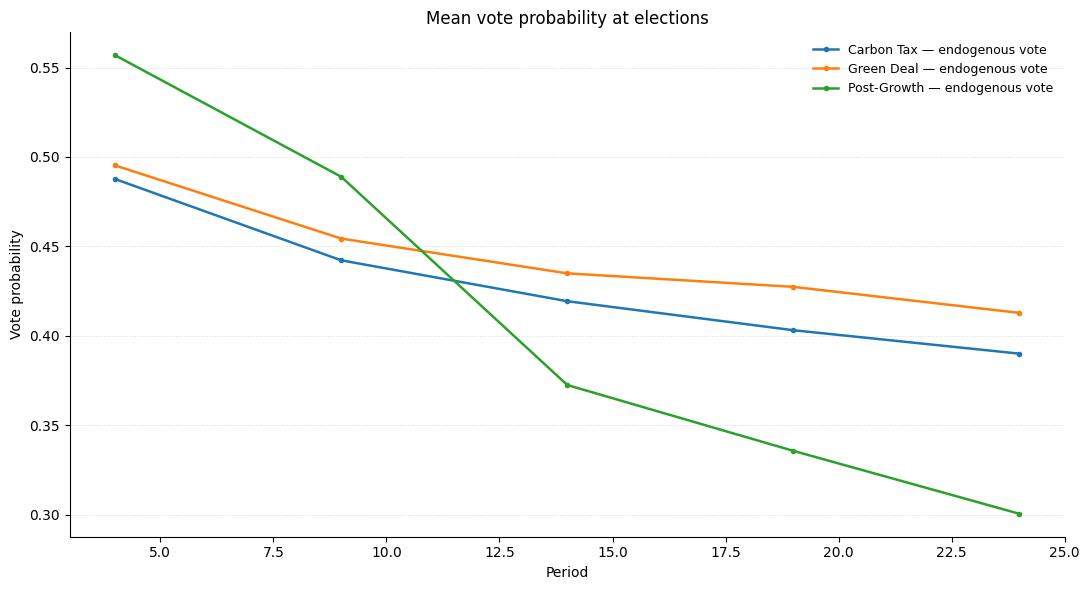

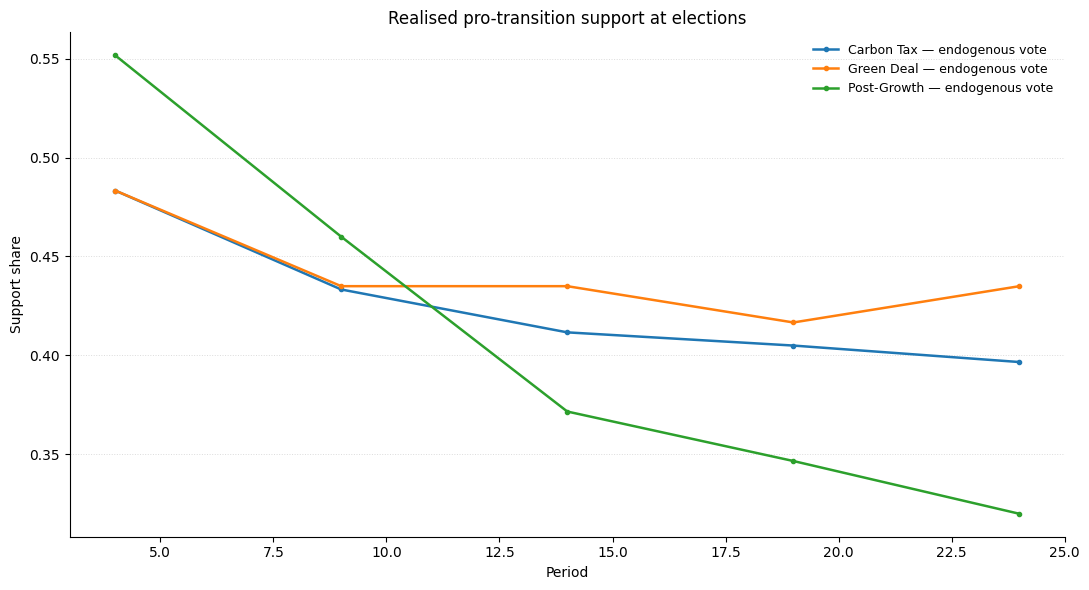

In [9]:
VOTE_EXPERIMENTS = [
    "E2_carbon_tax_vote",
    "E4_green_deal_vote",
    "E6_post_growth_vote",
]
ELECTION_PERIODS = CONFIG["run_control"]["election_periods"]

if "mean_vote_probability" in period_tables:
    vote_probability_elections = period_tables["mean_vote_probability"]
    vote_probability_elections = vote_probability_elections[
        vote_probability_elections["experiment_id"].isin(VOTE_EXPERIMENTS)
        & vote_probability_elections["period"].isin(ELECTION_PERIODS)
    ]
    plot_trajectories(
        vote_probability_elections,
        "mean_vote_probability",
        "Mean vote probability at elections",
        "Vote probability",
        "politics_vote_probability.png",
        experiments=VOTE_EXPERIMENTS,
    )

if "realised_support" in period_tables:
    support_elections = period_tables["realised_support"]
    support_elections = support_elections[
        support_elections["experiment_id"].isin(VOTE_EXPERIMENTS)
        & support_elections["period"].isin(ELECTION_PERIODS)
    ]
    plot_trajectories(
        support_elections,
        "realised_support",
        "Realised pro-transition support at elections",
        "Support share",
        "politics_realised_support.png",
        experiments=VOTE_EXPERIMENTS,
    )


## Comparaisons appariées FIXED / ENDOGENOUS

Le tableau calcule uniquement des différences descriptives entre les valeurs finales de chaque paire.


In [10]:
PAIRS = {
    "Carbon Tax": ("E1_carbon_tax_fixed", "E2_carbon_tax_vote"),
    "Green Deal": ("E3_green_deal_fixed", "E4_green_deal_vote"),
    "Post-Growth": ("E5_post_growth_fixed", "E6_post_growth_vote"),
}

final_contrasts = []

for metric_name, table in period_tables.items():
    value_column = metric_name
    if value_column not in table.columns:
        continue

    last_period = table["period"].max()
    final_values = (
        table[table["period"] == last_period]
        .set_index("experiment_id")[value_column]
    )

    for package, (fixed_id, vote_id) in PAIRS.items():
        if fixed_id not in final_values.index or vote_id not in final_values.index:
            continue
        fixed_value = float(final_values.loc[fixed_id])
        vote_value = float(final_values.loc[vote_id])
        final_contrasts.append(
            {
                "package": package,
                "metric": metric_name,
                "fixed_value": fixed_value,
                "endogenous_value": vote_value,
                "endogenous_minus_fixed": vote_value - fixed_value,
            }
        )

final_contrasts_df = pd.DataFrame(final_contrasts)
final_contrasts_df.to_csv(
    OUTPUT_ROOT / "final_fixed_endogenous_contrasts.csv",
    index=False,
)

if "real_gdp" in period_tables:
    for package, (fixed_id, vote_id) in PAIRS.items():
        plot_trajectories(
            period_tables["real_gdp"], "real_gdp",
            f"{package}: FIXED versus ENDOGENOUS",
            "Real GDP (period-0 prices)",
            f"pair_{package.lower().replace(' ', '_').replace('-', '_')}_real_gdp.png",
            experiments=[fixed_id, vote_id],
        )

final_contrasts_df


,package,metric,fixed_value,endogenous_value,endogenous_minus_fixed
0,Carbon Tax,mean_needs_index,1.016926e+02,102.207444,0.514803
1,Green Deal,mean_needs_index,1.040995e+02,103.940627,-0.158846
2,Post-Growth,mean_needs_index,1.078992e+02,99.676915,-8.222286
3,Carbon Tax,mean_disposable_income,8.427418e+01,86.808830,2.534649
4,Green Deal,mean_disposable_income,9.952823e+01,95.139708,-4.388519
5,Post-Growth,mean_disposable_income,8.642421e+01,67.404730,-19.019480
6,Carbon Tax,mean_vote_probability,NaN,0.392463,NaN
7,Green Deal,mean_vote_probability,NaN,0.409348,NaN
8,Post-Growth,mean_vote_probability,NaN,0.333349,NaN
9,Carbon Tax,realised_support,-1.000000e+00,0.408333,1.408333


## Distribution du NeedsIndex à la dernière période

Ce graphique utilise directement les observations individuelles des ménages.


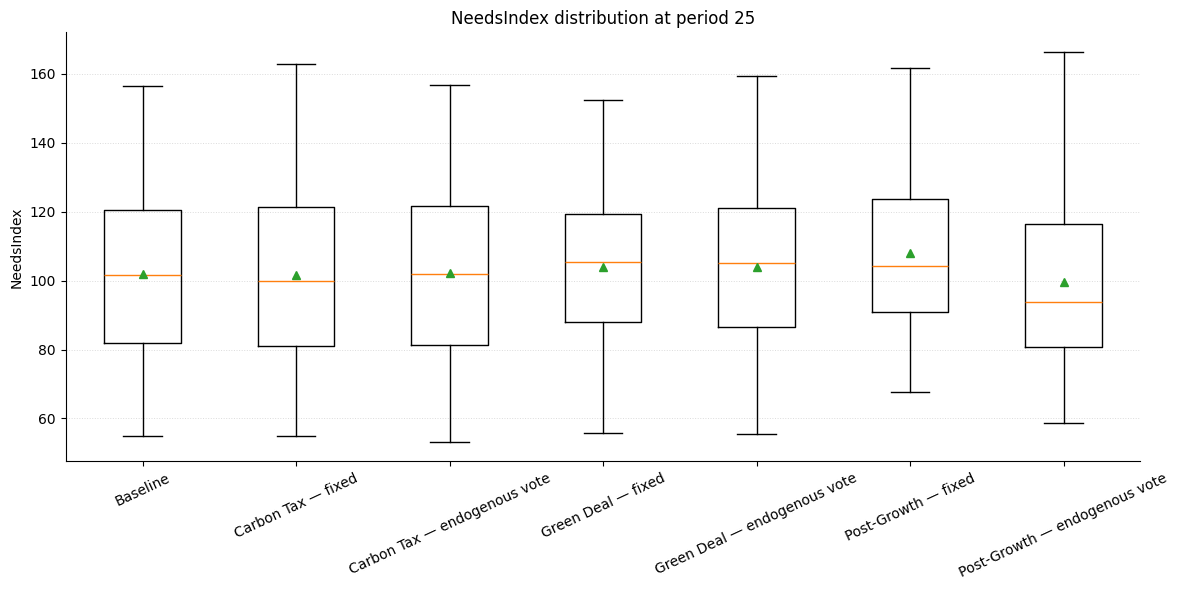

In [11]:
if needs_col:
    last_period = households["period"].max()
    needs_final = households[households["period"] == last_period].copy()
    needs_final["experiment_label"] = pd.Categorical(
        needs_final["experiment_label"],
        categories=[LABELS[item] for item in EXPERIMENT_ORDER],
        ordered=True,
    )

    grouped = [
        needs_final.loc[
            needs_final["experiment_id"] == experiment_id,
            needs_col,
        ].dropna().to_numpy()
        for experiment_id in EXPERIMENT_ORDER
    ]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(
        grouped,
        tick_labels=[LABELS[item] for item in EXPERIMENT_ORDER],
        showfliers=False,
        showmeans=True,
    )
    ax.set_title(f"NeedsIndex distribution at period {last_period}")
    ax.set_ylabel("NeedsIndex")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig(
        FIGURE_ROOT / "needs_index_final_distribution.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## Export des tables agrégées


In [12]:
aggregate_dir = OUTPUT_ROOT / "aggregates"
aggregate_dir.mkdir(parents=True, exist_ok=True)

for name, table in period_tables.items():
    table.to_csv(aggregate_dir / f"{name}.csv", index=False)

from senharp_core.reporting import export_standard_tables
export_standard_tables(
    output_root=OUTPUT_ROOT, period_tables=period_tables, macro=macro,
    households=households, election_periods=CONFIG["run_control"]["election_periods"],
)

print("Aggregates:", aggregate_dir)
print("Figures:", FIGURE_ROOT)


Aggregates: C:\Users\saintjea\MesNotebooks\SEN_HARP\senharp_core_v0.4\outputs\seven_experiments\aggregates
Figures: C:\Users\saintjea\MesNotebooks\SEN_HARP\senharp_core_v0.4\outputs\seven_experiments\figures
